# Inspect Raw DICOM Before Dataset Creation

This notebook is for understanding the **raw source data first** (before conversion to `fixed.nii.gz` and `moving.nii.gz`).

You will see why many `.dcm` files become only 2 output images:
- one selected T2 series from the earlier study (`fixed`)
- one selected T2 series from the later study (`moving`)

Important concept:
- A single MRI series contains many DICOM slices (`.dcm`)
- Converting one series produces one 3D volume (`.nii.gz`)


In [1]:
from pathlib import Path
from collections import defaultdict
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 6)
np.set_printoptions(suppress=True, precision=4)


In [2]:
# Change this patient id if you want to inspect another patient.
PROJECT_ROOT = Path.cwd()
PATIENT_DIR = PROJECT_ROOT / 'dataset' / 'raw' / 'qin_prostate_repeatability' / 'PCAMPMRI-00001'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PATIENT_DIR :', PATIENT_DIR)
print('Exists      :', PATIENT_DIR.exists())

if not PATIENT_DIR.exists():
    raise FileNotFoundError('Raw patient directory not found. Check path.')


PROJECT_ROOT: /Users/rifqiab2708/Documents/img_regist
PATIENT_DIR : /Users/rifqiab2708/Documents/img_regist/dataset/raw/qin_prostate_repeatability/PCAMPMRI-00001
Exists      : True


## 1) Understand folder hierarchy

Hierarchy in this dataset:
- `PCAMPMRI-xxxxx` (patient)
- `study_uid/` (visit/timepoint)
- `MR_*`, `SEG_*`, `SR_*` (series)
- `.dcm` files inside each series


In [3]:
study_dirs = sorted([p for p in PATIENT_DIR.iterdir() if p.is_dir()])
print('Number of studies:', len(study_dirs))
for s in study_dirs:
    print('-', s.name)


Number of studies: 2
- 1.3.6.1.4.1.14519.5.2.1.3671.4754.121472087445374646718121301133
- 1.3.6.1.4.1.14519.5.2.1.3671.4754.288848219213026850354055725664


In [4]:
def classify_series(name: str) -> str:
    if name.startswith('MR_'):
        return 'MR'
    if name.startswith('SEG_'):
        return 'SEG'
    if name.startswith('SR_'):
        return 'SR'
    return 'OTHER'

for study in study_dirs:
    series_dirs = sorted([p for p in study.iterdir() if p.is_dir()])
    counts = defaultdict(int)
    for ser in series_dirs:
        counts[classify_series(ser.name)] += 1

    print(f'\nStudy {study.name}')
    print('  total series:', len(series_dirs))
    print('  counts      :', dict(counts))

    for ser in series_dirs:
        dcm_count = len(list(ser.glob('*.dcm')))
        print(f'   - {ser.name} | type={classify_series(ser.name):<5} | dcm={dcm_count}')



Study 1.3.6.1.4.1.14519.5.2.1.3671.4754.121472087445374646718121301133
  total series: 11
  counts      : {'MR': 5, 'SEG': 3, 'SR': 3}
   - MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.126754929065360874547842580090 | type=MR    | dcm=16
   - MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.265098529377163570903484927387 | type=MR    | dcm=20
   - MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.304687867361307709880533673080 | type=MR    | dcm=864
   - MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.340967763797966622706944397525 | type=MR    | dcm=40
   - MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.983460207615355998147518323000 | type=MR    | dcm=30
   - SEG_1.2.276.0.7230010.3.1.3.1426846371.16056.1513205118.345 | type=SEG   | dcm=1
   - SEG_1.2.276.0.7230010.3.1.3.1426846371.5332.1513205117.172 | type=SEG   | dcm=1
   - SEG_1.2.276.0.7230010.3.1.3.1426846371.6596.1513205116.412 | type=SEG   | dcm=1
   - SR_1.2.276.0.7230010.3.1.3.3166326398.14852.1513205118.24 | type=SR    | dcm=1
   - SR_1.2.276.0.7230010.3.1.3.3166326398.19544

## 2) Read DICOM metadata for each MR series

We read tags from the first DICOM file in each MR series:
- `StudyDate` (`0008|0020`)
- `Modality` (`0008|0060`)
- `SeriesDescription` (`0008|103e`)
- `SequenceName` (`0018|0024`)
- `PixelSpacing` (`0028|0030`)


In [5]:
TAG_STUDY_DATE = '0008|0020'
TAG_MODALITY = '0008|0060'
TAG_DESC = '0008|103e'
TAG_SEQUENCE = '0018|0024'
TAG_SPACING = '0028|0030'

def get_tag(reader: sitk.ImageFileReader, tag: str) -> str:
    return reader.GetMetaData(tag).strip() if reader.HasMetaDataKey(tag) else ''

mr_rows = []

for study in study_dirs:
    for ser in sorted([p for p in study.iterdir() if p.is_dir() and p.name.startswith('MR_')]):
        dcm_files = sorted(ser.glob('*.dcm'))
        if not dcm_files:
            continue

        reader = sitk.ImageFileReader()
        reader.SetFileName(str(dcm_files[0]))
        reader.LoadPrivateTagsOn()
        reader.ReadImageInformation()

        row = {
            'study_uid': study.name,
            'series_uid': ser.name,
            'slice_count': len(dcm_files),
            'study_date': get_tag(reader, TAG_STUDY_DATE),
            'modality': get_tag(reader, TAG_MODALITY),
            'series_description': get_tag(reader, TAG_DESC),
            'sequence_name': get_tag(reader, TAG_SEQUENCE),
            'pixel_spacing': get_tag(reader, TAG_SPACING),
            'series_path': ser,
        }
        mr_rows.append(row)

print('MR series found:', len(mr_rows))
for r in mr_rows:
    print('\nSeries:', r['series_uid'])
    print('  study_date        :', r['study_date'])
    print('  modality          :', r['modality'])
    print('  series_description:', r['series_description'])
    print('  sequence_name     :', r['sequence_name'])
    print('  pixel_spacing     :', r['pixel_spacing'])
    print('  slice_count       :', r['slice_count'])


MR series found: 10

Series: MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.126754929065360874547842580090
  study_date        : 19940620
  modality          : MR
  series_description: DCE Subtraction
  sequence_name     : 
  pixel_spacing     : 1.0156\1.0156
  slice_count       : 16

Series: MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.265098529377163570903484927387
  study_date        : 19940620
  modality          : MR
  series_description: Apparent Diffusion Coefficient
  sequence_name     : 
  pixel_spacing     : 0.703100\0.703100
  slice_count       : 20

Series: MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.304687867361307709880533673080
  study_date        : 19940620
  modality          : MR
  series_description: DCE
  sequence_name     : 
  pixel_spacing     : 1.0156\1.0156
  slice_count       : 864

Series: MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.340967763797966622706944397525
  study_date        : 19940620
  modality          : MR
  series_description: DWI
  sequence_name     : 
  pixel_spacing     : 0.7

## 3) Reproduce the selection logic from `prepare_qin_registration_dataset.py`

The script keeps only MR T2 candidates by description keywords:
- include if contains one of: `T2`, `T2W`, `TSE`, `AX T2`
- exclude if contains one of: `ADC`, `DWI`, `BVAL`, `DCE`

Then:
- earliest study date -> fixed
- latest study date -> moving
- choose best T2 series in each study


In [6]:
INCLUDE_KEYWORDS = ['T2', 'T2W', 'TSE', 'AX T2']
EXCLUDE_KEYWORDS = ['ADC', 'DWI', 'BVAL', 'DCE']

def contains_any(text: str, keywords: list[str]) -> bool:
    t = (text or '').upper()
    return any(k.upper() in t for k in keywords)

by_study = defaultdict(list)
for r in mr_rows:
    by_study[r['study_uid']].append(r)

study_date_map = {}
for study_uid, rows in by_study.items():
    dates = sorted({r['study_date'] for r in rows if r['study_date']})
    if len(dates) == 1:
        study_date_map[study_uid] = dates[0]

print('Study dates:')
for k, v in sorted(study_date_map.items(), key=lambda x: x[1]):
    print(' ', k, '->', v)

ordered = sorted(study_date_map.items(), key=lambda x: x[1])
fixed_study_uid = ordered[0][0]
moving_study_uid = ordered[-1][0]
print('\nFixed study UID :', fixed_study_uid)
print('Moving study UID:', moving_study_uid)

def t2_candidates(rows: list[dict]) -> list[dict]:
    out = []
    for r in rows:
        desc = r['series_description']
        include_ok = contains_any(desc, INCLUDE_KEYWORDS)
        exclude_hit = contains_any(desc, EXCLUDE_KEYWORDS)
        modality_ok = (r['modality'].upper() == 'MR') if r['modality'] else True
        if modality_ok and include_ok and not exclude_hit:
            out.append(r)
    return out

fixed_candidates = t2_candidates(by_study[fixed_study_uid])
moving_candidates = t2_candidates(by_study[moving_study_uid])

print('\nFixed candidates:')
for r in fixed_candidates:
    print(' ', r['series_uid'], '|', r['series_description'], '| slices=', r['slice_count'])

print('\nMoving candidates:')
for r in moving_candidates:
    print(' ', r['series_uid'], '|', r['series_description'], '| slices=', r['slice_count'])


Study dates:
  1.3.6.1.4.1.14519.5.2.1.3671.4754.121472087445374646718121301133 -> 19940620
  1.3.6.1.4.1.14519.5.2.1.3671.4754.288848219213026850354055725664 -> 19940702

Fixed study UID : 1.3.6.1.4.1.14519.5.2.1.3671.4754.121472087445374646718121301133
Moving study UID: 1.3.6.1.4.1.14519.5.2.1.3671.4754.288848219213026850354055725664

Fixed candidates:
  MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.983460207615355998147518323000 | T2 Weighted Axial | slices= 30

Moving candidates:
  MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.609837242670719860929372097937 | T2 Weighted Axial | slices= 30


In [7]:
# Same tie-break style used in the script.
def choose_t2(candidates: list[dict]) -> dict | None:
    if not candidates:
        return None
    if len(candidates) == 1:
        return candidates[0]

    max_slices = max(r['slice_count'] for r in candidates)
    top = [r for r in candidates if r['slice_count'] == max_slices]
    if len(top) == 1:
        return top[0]

    spacing_counts = defaultdict(int)
    for r in candidates:
        spacing_counts[r['pixel_spacing'] or 'UNKNOWN'] += 1
    modal_spacing = sorted(spacing_counts.items(), key=lambda x: (-x[1], x[0]))[0][0]

    top2 = [r for r in top if (r['pixel_spacing'] or 'UNKNOWN') == modal_spacing]
    if len(top2) == 1:
        return top2[0]

    return sorted(top2, key=lambda r: r['series_uid'])[0]

fixed_selected = choose_t2(fixed_candidates)
moving_selected = choose_t2(moving_candidates)

print('Selected fixed series :', fixed_selected['series_uid'])
print('Selected moving series:', moving_selected['series_uid'])
print('\nReason this becomes 2 outputs:')
print('- One selected series from fixed study (earliest date)')
print('- One selected series from moving study (latest date)')


Selected fixed series : MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.983460207615355998147518323000
Selected moving series: MR_1.3.6.1.4.1.14519.5.2.1.3671.4754.609837242670719860929372097937

Reason this becomes 2 outputs:
- One selected series from fixed study (earliest date)
- One selected series from moving study (latest date)


## 4) Load selected raw DICOM series directly (without prepared NIfTI)

This proves one MR series (many `.dcm`) can be read as one 3D image.


In [8]:
def read_series_as_image(series_dir: Path) -> sitk.Image:
    reader = sitk.ImageSeriesReader()
    file_names = reader.GetGDCMSeriesFileNames(str(series_dir))
    reader.SetFileNames(file_names)
    return reader.Execute()

fixed_raw_img = read_series_as_image(fixed_selected['series_path'])
moving_raw_img = read_series_as_image(moving_selected['series_path'])

print('fixed_raw_img size :', fixed_raw_img.GetSize())
print('moving_raw_img size:', moving_raw_img.GetSize())
print('fixed series dcm count :', fixed_selected['slice_count'])
print('moving series dcm count:', moving_selected['slice_count'])


fixed_raw_img size : (512, 512, 30)
moving_raw_img size: (512, 512, 30)
fixed series dcm count : 30
moving series dcm count: 30


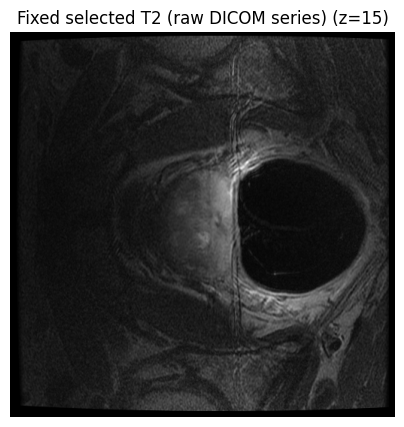

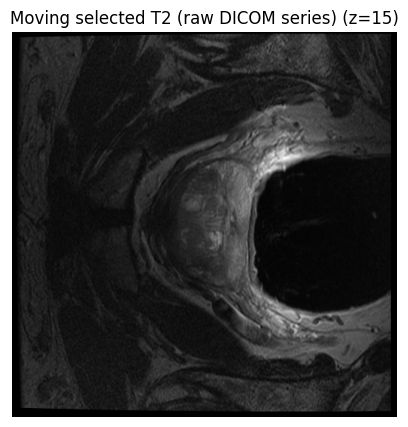

In [9]:
fixed_arr = sitk.GetArrayFromImage(fixed_raw_img)
moving_arr = sitk.GetArrayFromImage(moving_raw_img)

def show_center_slice(arr: np.ndarray, title: str):
    zc = arr.shape[0] // 2
    plt.figure(figsize=(5, 5))
    plt.imshow(np.rot90(arr[zc]), cmap='gray')
    plt.title(f'{title} (z={zc})')
    plt.axis('off')
    plt.show()

show_center_slice(fixed_arr, 'Fixed selected T2 (raw DICOM series)')
show_center_slice(moving_arr, 'Moving selected T2 (raw DICOM series)')


## 5) Manual inspection checklist

When inspecting raw data manually, verify:
1. Which studies exist (dates)
2. Which MR series exist in each study
3. Series descriptions (T2 vs DWI/ADC/DCE)
4. Slice counts and spacing
5. Visual quality of selected T2 slices
